# Modal Analysis on an MDOF System

## Introduction

This notebook demonstrates a structured workflow for running a modal analysis on a calibrated multi-degree-of-freedom (MDOF) stick model derived from an SDOF spectral capacity curve.

Two steps are covered:

1. **Calibrate and compile an MDOF model** — Derive per-storey force-deformation backbones from an SDOF capacity curve (Sd–Sa) using the `calibrate_model` function, then assemble the OpenSees stick model with the `modeller` class.

2. **Run modal analysis** — Compute natural periods, mode shapes, and modal participation factors for the calibrated MDOF system using OpenSees eigenvalue analysis.

## Initialise Libraries

In [5]:
import numpy as np

from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.modeller import modeller
from openquake.vmtk.units import units

## Calibrate an MDOF Model from an SDOF Capacity Curve

In [6]:
# Number of storeys
number_storeys = 9

# Relative floor heights list
storey_heights = [2.80] * number_storeys

# SDOF capacity with a trilinear backbone
sdof_capacity = np.array(
    [
        [0.009891, 0.079128, 0.2142],    # spectral displacements [m]
        [0.2356000, 0.4712500, 0.47596],  # spectral accelerations [g]
    ]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = False

# Inherent damping
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~
Stopped because of load factor below zero


WARNING ZeroLength::setDomain(): Element 2000 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2004 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2005 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2006 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2007 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2008 has L= 1, which is greater than the tolerance


## Compile the MDOF Model

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2004 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2005 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2006 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2007 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2008 has L= 2.8, which is greater than the tolerance


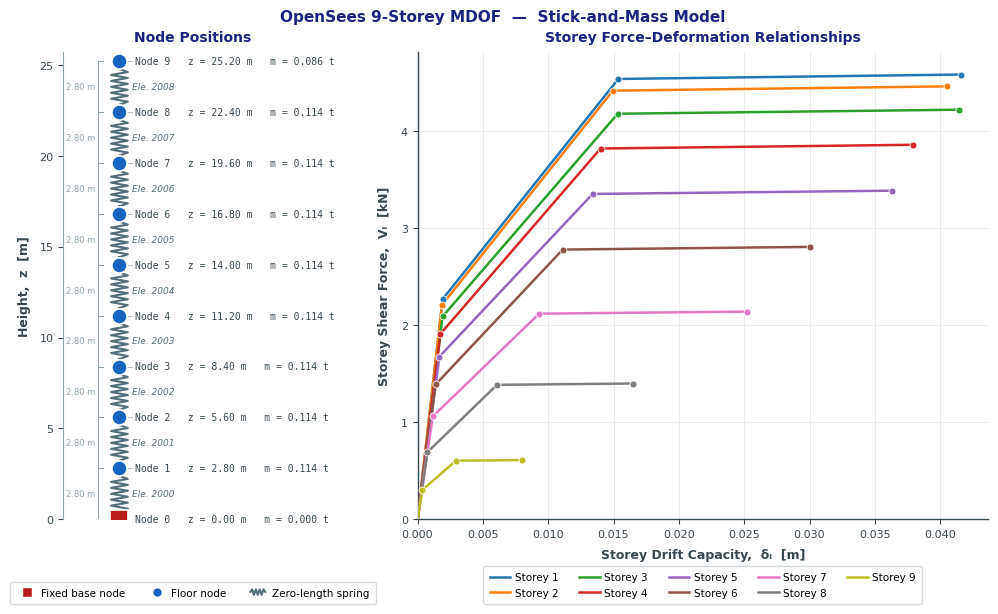

In [7]:
# Initialise the modeller class and compile the MDOF model
model = modeller(
    number_storeys,
    storey_heights,
    floor_masses,
    storey_drifts,
    storey_forces * units.g,
    mdof_degradation,
)
model.compile_model()

# Visualise the stick model
model.plot_model(pFlag=True, export_path="./out/mdof_model.png")

# Do gravity analysis for system equilibrium
model.do_gravity_analysis()

## Run Modal Analysis

After compiling the model, `do_modal_analysis` solves the generalised eigenvalue problem K·φ = ω²·M·φ to extract natural periods and mode shapes. Setting `pFlag=True` prints a modal summary to the console; `plot_modes=True` renders all extracted mode shapes against the undeformed stick geometry and saves the figure to `export_path` if provided.

Fundamental Period: T = 0.379 s


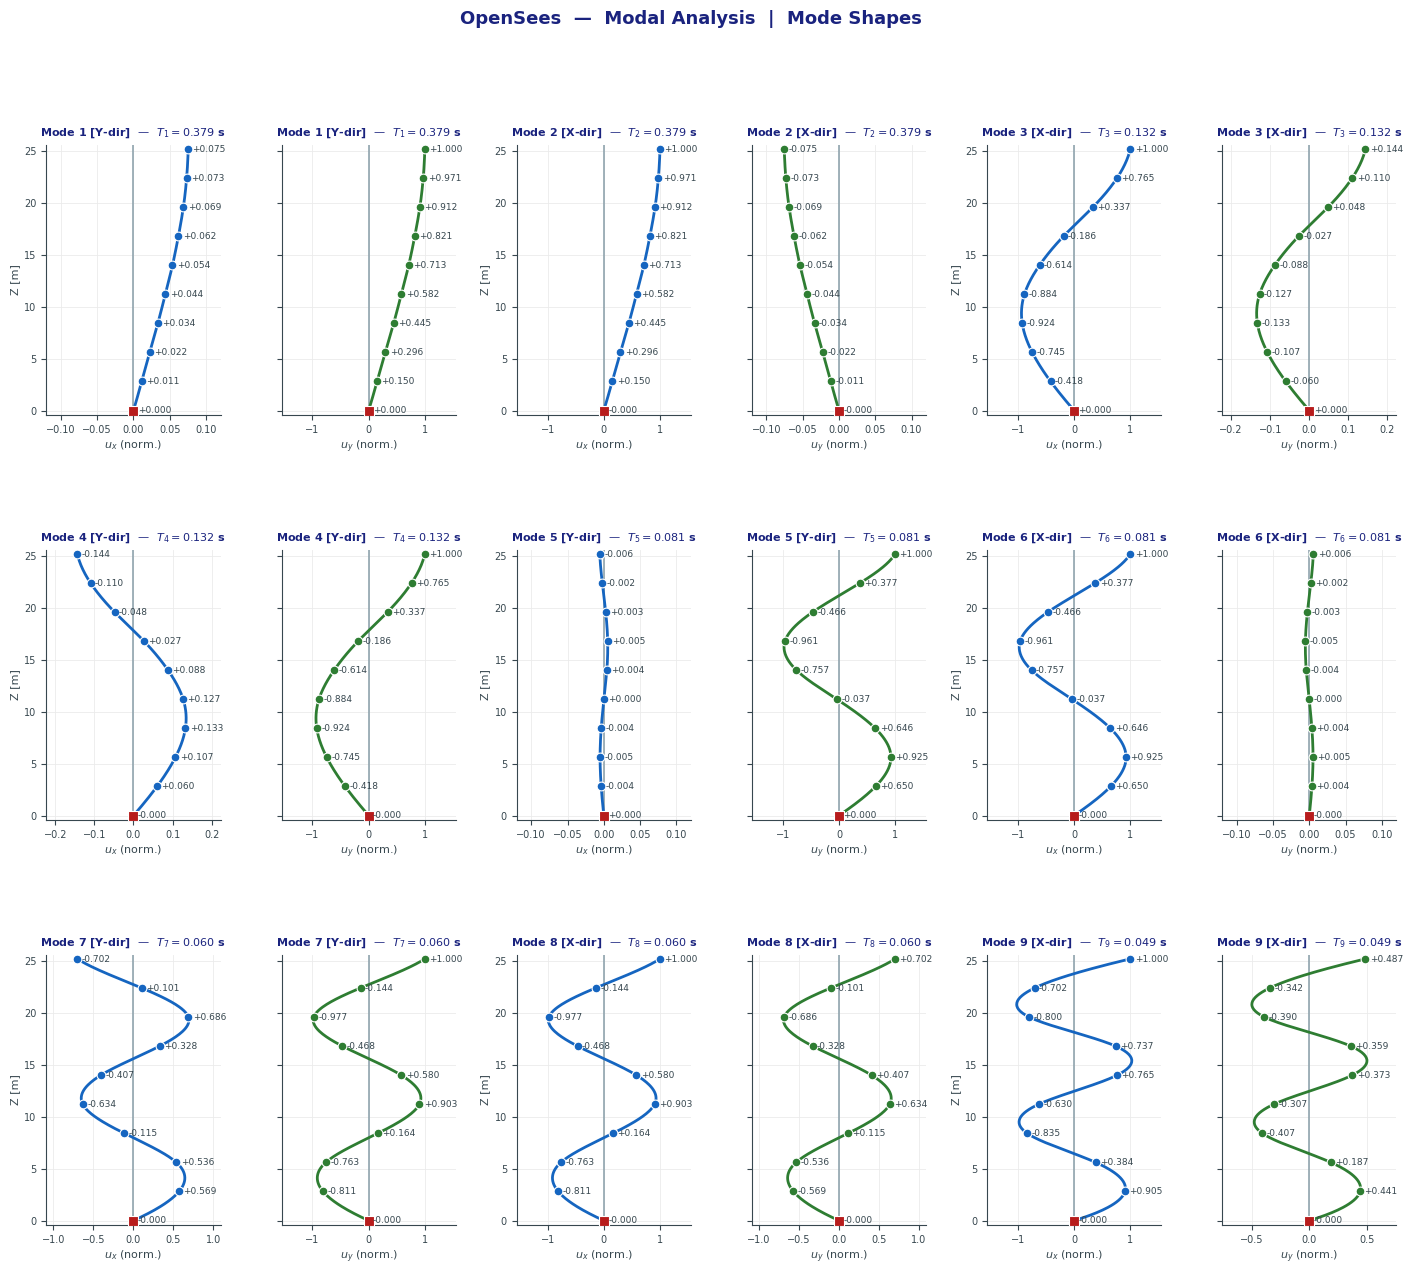

In [8]:
# Do modal analysis
num_modes = 9
T, phi = model.do_modal_analysis(
    num_modes=num_modes,  # Get N-modes
    pFlag=True,  # Prints modal analysis report
    plot_modes=True,  # Plots modal analysis results
    export_path="out/modal_analysis.png",
)  # Exports modal analysis results